# 06 — Exploratory: Q4 2025 RSV spike analysis (post-hoc)

**Purpose:** Identify which countries drive the sharp increase in global mean RSV  
observed in Q4 2025 (October–December 2025) in H2a and the simultaneous drop  
in EBT ratio in H2b.

**Note:** This is an exploratory analysis outside the pre-registered hypotheses.  
Results are not reported as primary findings.

**Context:** A notable increase in global mean RSV was observed in late 2025,  
driven by a subset of countries. The nature of this increase — whether reflecting  
genuine growth in help-seeking behaviour or a Google Trends normalisation artefact  
— warrants further investigation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────────
DATA_DIR   = Path('../data')
OUTPUT_DIR = Path('../results/exploratory_Q4_2025')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Parameters ─────────────────────────────────────────────────────────────────
CATEGORIES = ['evidence_based_treatments', 'general_help_seeking']

Q3_START = pd.Timestamp('2025-07-01')
Q3_END   = pd.Timestamp('2025-09-30')
Q4_START = pd.Timestamp('2025-10-01')
Q4_END   = pd.Timestamp('2025-12-31')

print('Setup complete.')

Setup complete.


In [2]:
# ── Data loading function (same as H2a notebook) ───────────────────────────────
def load_country_category(country_dir: Path, category: str) -> pd.DataFrame | None:
    csv_files = sorted(country_dir.glob(f'{category}__*__chunk*.csv'))
    if not csv_files:
        return None
    frames = []
    for f in csv_files:
        try:
            df = pd.read_csv(f, parse_dates=['date'], index_col='date')
            if 'isPartial' in df.columns:
                df = df[df['isPartial'] == False].drop(columns=['isPartial'])
            numeric_cols = df.select_dtypes(include='number').columns
            if len(numeric_cols) > 0:
                frames.append(df[numeric_cols])
        except Exception:
            continue
    if not frames:
        return None
    combined = pd.concat(frames, axis=1)
    combined = combined.loc[:, ~combined.columns.duplicated()]
    return combined


def load_panel(category: str) -> pd.DataFrame:
    """Load mean RSV per country for a given category."""
    country_series = {}
    raw_dir = sorted(DATA_DIR.glob('raw_*'))
    if not raw_dir:
        raise FileNotFoundError(f'No raw_* directory found in {DATA_DIR}')
    latest = raw_dir[-1]

    for country_dir in sorted(latest.iterdir()):
        if not country_dir.is_dir():
            continue
        country = country_dir.name
        df = load_country_category(country_dir, category)
        if df is None or df.empty:
            continue
        country_series[country] = df.mean(axis=1)

    panel = pd.DataFrame(country_series)
    panel.index = pd.to_datetime(panel.index)
    return panel.sort_index()


print('Loading data...')
panels = {cat: load_panel(cat) for cat in CATEGORIES}
for cat, panel in panels.items():
    print(f'{cat}: {panel.shape[1]} countries, {panel.shape[0]} months')

Loading data...
evidence_based_treatments: 21 countries, 96 months
general_help_seeking: 21 countries, 96 months


In [3]:
# ── Q3 vs Q4 2025: mean RSV per country ───────────────────────────────────────
print('=' * 70)
print('Q3 2025 vs Q4 2025 — Mean RSV by Country')
print('=' * 70)

results = {}

for cat in CATEGORIES:
    panel = panels[cat]

    q3 = panel[(panel.index >= Q3_START) & (panel.index <= Q3_END)].mean()
    q4 = panel[(panel.index >= Q4_START) & (panel.index <= Q4_END)].mean()

    df_cmp = pd.DataFrame({'Q3_2025': q3, 'Q4_2025': q4})
    df_cmp['change'] = df_cmp['Q4_2025'] - df_cmp['Q3_2025']
    df_cmp['change_pct'] = (df_cmp['change'] / df_cmp['Q3_2025'] * 100).round(1)
    df_cmp = df_cmp.sort_values('change', ascending=False)

    results[cat] = df_cmp

    print(f'\nCategory: {cat}')
    print(f'{"Country":<8} {"Q3_2025":>10} {"Q4_2025":>10} {"Change":>10} {"Change%":>10}')
    print('-' * 52)
    for country, row in df_cmp.iterrows():
        marker = ' ←' if abs(row['change']) > 5 else ''
        print(f'{country:<8} {row["Q3_2025"]:>10.2f} {row["Q4_2025"]:>10.2f} '
              f'{row["change"]:>+10.2f} {row["change_pct"]:>9.1f}%{marker}')

Q3 2025 vs Q4 2025 — Mean RSV by Country

Category: evidence_based_treatments
Country     Q3_2025    Q4_2025     Change    Change%
----------------------------------------------------
JP             9.25      20.76     +11.51     124.5% ←
BR            12.32      21.67      +9.35      75.9% ←
PL            13.14      21.57      +8.43      64.1% ←
IL             7.08      15.42      +8.33     117.6% ←
CA            22.46      30.14      +7.68      34.2% ←
FR            13.79      21.39      +7.60      55.1% ←
KZ             5.00      11.86      +6.86     137.3% ←
NL            14.20      20.98      +6.78      47.8% ←
DE            18.42      24.68      +6.26      34.0% ←
GE             2.52       8.39      +5.87     232.6% ←
UA             7.05      11.95      +4.90      69.6%
UZ             1.23       6.05      +4.82     393.6%
AZ             1.06       5.75      +4.69     443.5%
US            31.40      36.00      +4.60      14.6%
AM             1.24       5.10      +3.86     311.5%
G

In [4]:
# ── EBT Ratio Q3 vs Q4 2025 ───────────────────────────────────────────────────
print('=' * 70)
print('EBT Ratio (EBT / General help-seeking) — Q3 vs Q4 2025')
print('=' * 70)

ebt   = panels['evidence_based_treatments']
gen   = panels['general_help_seeking']

ratio = ebt.divide(gen.where(gen > 0))

q3_ratio = ratio[(ratio.index >= Q3_START) & (ratio.index <= Q3_END)].mean()
q4_ratio = ratio[(ratio.index >= Q4_START) & (ratio.index <= Q4_END)].mean()

df_ratio = pd.DataFrame({'Q3_ratio': q3_ratio, 'Q4_ratio': q4_ratio})
df_ratio['change'] = df_ratio['Q4_ratio'] - df_ratio['Q3_ratio']
df_ratio = df_ratio.sort_values('change')

print(f'{"Country":<8} {"Q3_ratio":>10} {"Q4_ratio":>10} {"Change":>10}')
print('-' * 42)
for country, row in df_ratio.iterrows():
    marker = ' ←' if abs(row['change']) > 0.5 else ''
    print(f'{country:<8} {row["Q3_ratio"]:>10.3f} {row["Q4_ratio"]:>10.3f} '
          f'{row["change"]:>+10.3f}{marker}')

EBT Ratio (EBT / General help-seeking) — Q3 vs Q4 2025
Country    Q3_ratio   Q4_ratio     Change
------------------------------------------
JP           12.535      2.418    -10.116 ←
BR            4.832      1.876     -2.956 ←
IL            3.355      1.097     -2.258 ←
DE            1.469      1.133     -0.335
FR            1.074      0.842     -0.232
LT            0.631      0.506     -0.126
NL            1.057      0.937     -0.121
PL            1.017      0.919     -0.098
GB            0.522      0.469     -0.053
AU            0.604      0.571     -0.033
CA            0.815      0.811     -0.004
UZ            0.363      0.387     +0.024
UA            0.460      0.490     +0.030
US            0.872      0.905     +0.033
LV            0.349      0.416     +0.067
KZ            0.484      0.592     +0.108
AZ            0.480      0.674     +0.194
EE            0.518      1.039     +0.521 ←
GE            0.462      0.995     +0.533 ←
AM              nan      0.849       +nan
MD        

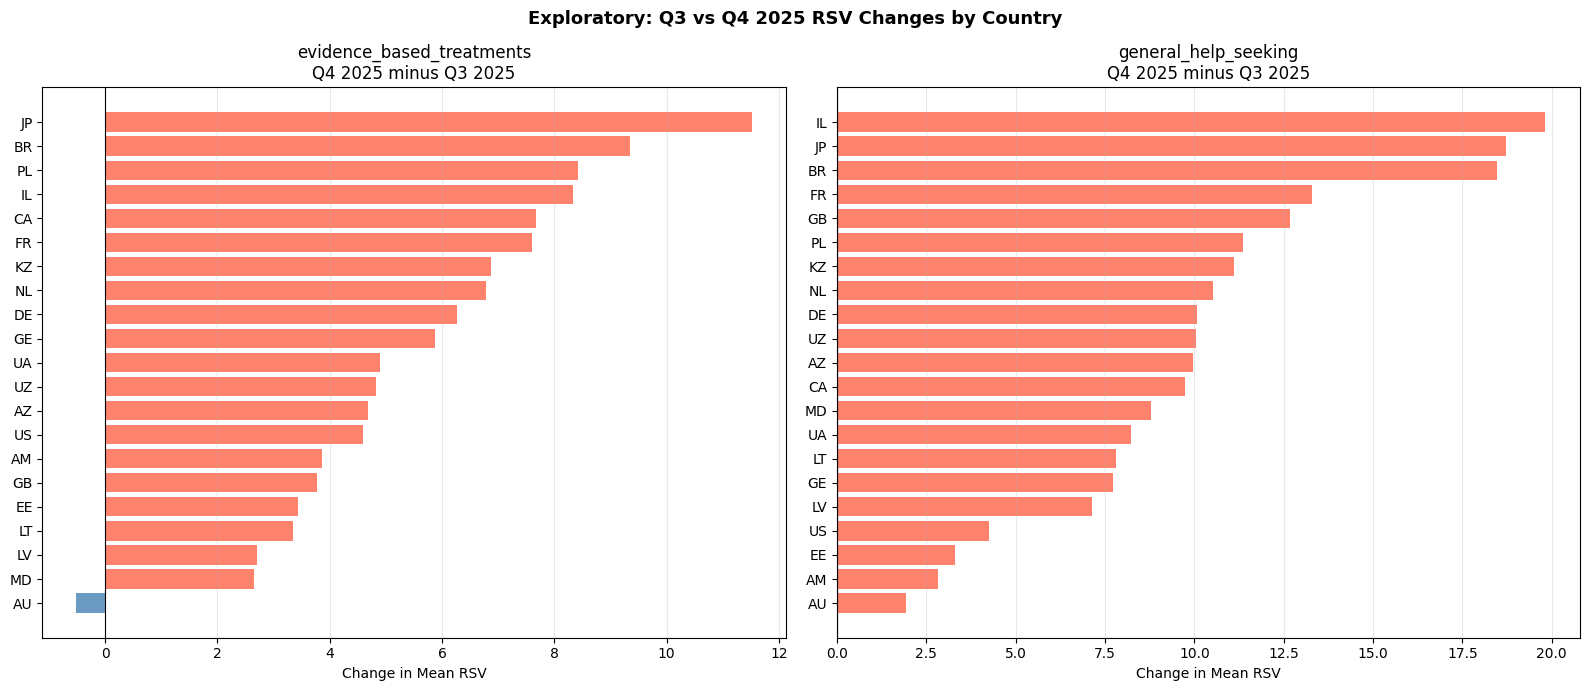

Figure saved.


In [5]:
# ── Visualization ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Exploratory: Q3 vs Q4 2025 RSV Changes by Country', 
             fontsize=13, fontweight='bold')

for ax, cat in zip(axes, CATEGORIES):
    df_cmp = results[cat].sort_values('change', ascending=True)
    colors = ['tomato' if v > 0 else 'steelblue' for v in df_cmp['change']]
    ax.barh(df_cmp.index, df_cmp['change'], color=colors, alpha=0.8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{cat}\nQ4 2025 minus Q3 2025')
    ax.set_xlabel('Change in Mean RSV')
    ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'Q4_2025_country_changes.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved.')

In [6]:
# ── Monthly detail: Q4 2025 by country ───────────────────────────────────────
print('Monthly RSV detail — evidence_based_treatments — Q4 2025')
print('=' * 70)

panel_ebt = panels['evidence_based_treatments']
q4_monthly = panel_ebt[panel_ebt.index >= Q4_START]

if len(q4_monthly) > 0:
    print(q4_monthly.round(1).to_string())
else:
    print('No Q4 2025 data available.')

Monthly RSV detail — evidence_based_treatments — Q4 2025
             AM    AU    AZ    BR    CA    DE   EE    FR    GB   GE    IL    JP    KZ   LT   LV   MD    NL    PL    UA    US   UZ
date                                                                                                                             
2025-10-01  1.5  26.3   1.8  13.8  25.2  17.5  3.2  14.1  21.8  5.9   6.7  10.8   7.1  4.9  1.9  1.8  16.0  16.9   7.5  33.6  3.3
2025-11-01  7.2  27.1  10.6  27.8  36.5  29.3  7.7  26.0  26.2  9.8  22.5  23.0  16.8  7.2  4.3  4.6  24.2  24.8  15.7  38.8  8.4
2025-12-01  6.6  22.2   4.8  23.4  28.7  27.2  7.4  24.0  23.8  9.5  17.1  28.5  11.7  9.5  7.4  5.7  22.7  23.0  12.7  35.6  6.5
